In [51]:
# Example: Simulate 3 federated clients
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("preprocessed_dataset.csv")
clients = []

# Split into 3 clients (e.g., by stratified sampling)
client1, temp = train_test_split(df, test_size=0.66, stratify=df['label'])
client2, client3 = train_test_split(temp, test_size=0.5, stratify=temp['label'])

clients = [client1, client2, client3]


In [52]:
from xgboost import XGBClassifier

local_models = []
for i, data in enumerate(clients):
    X = data.drop(columns=["label"])
    y = data["label"]
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X, y)
    local_models.append(model)


/home/neha/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:41:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/neha/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:41:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/neha/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:41:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [53]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 1: Load the datasets
train_df = pd.read_csv("preprocessed_dataset.csv")
test_df = pd.read_csv("combined_test.csv")

# Step 2: Split into features and labels
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]

# Step 3: Train the XGBoost model
model = XGBClassifier(eval_metric='logloss')  # No need for use_label_encoder
model.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = model.predict(X_test)

# Step 5: Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))


Accuracy: 0.9923333333333333
Classification Report:
              precision    recall  f1-score   support

           0     0.9802    0.9907    0.9854      1500
           1     0.9993    0.9993    0.9993      1500
           2     0.9993    0.9993    0.9993      1500
           3     0.9906    0.9800    0.9853      1500

    accuracy                         0.9923      6000
   macro avg     0.9924    0.9923    0.9923      6000
weighted avg     0.9924    0.9923    0.9923      6000



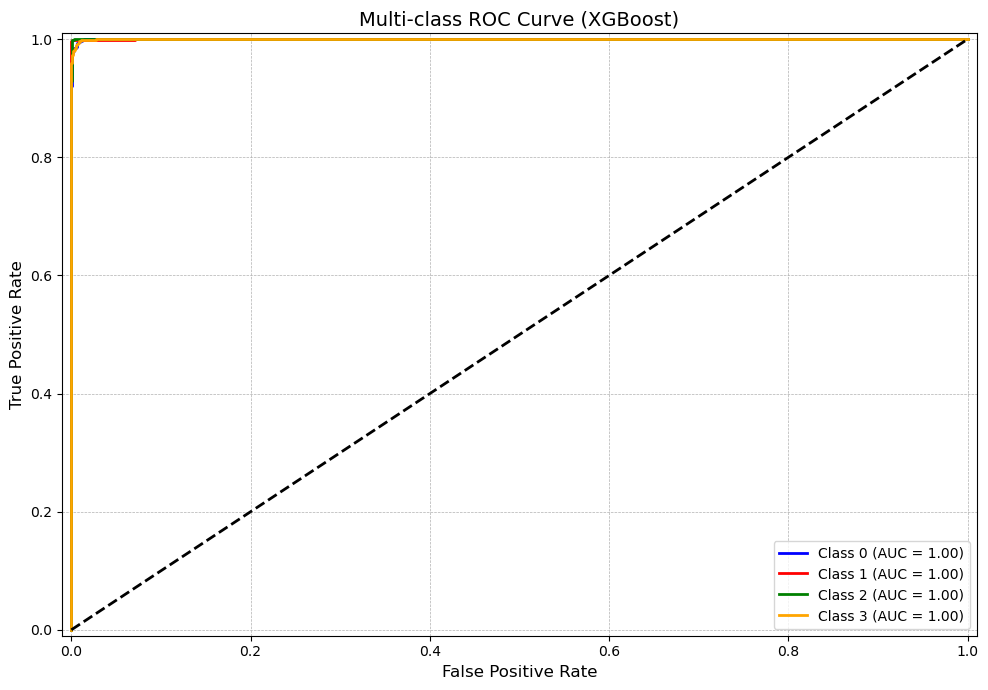

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize true labels
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_pred_proba = model.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'orange']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(
        fpr[i], tpr[i],
        color=colors[i],
        lw=2,
        label=f'Class {i} (AUC = {roc_auc[i]:.2f})'
    )

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Set axis limits with padding
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC Curve (XGBoost)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


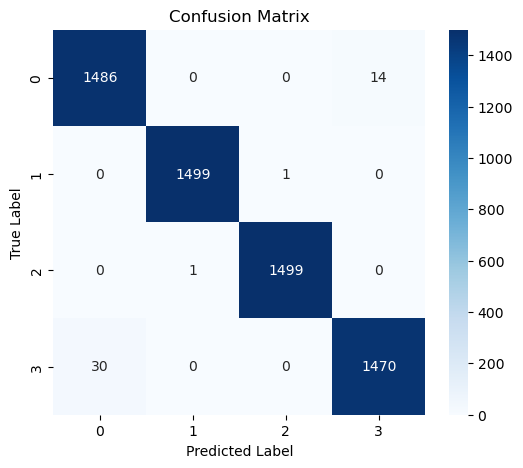

In [55]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [56]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define model with lighter config to speed up
model = XGBClassifier(
    eval_metric='logloss',
    n_estimators=50,       # Reduce boosting rounds
    max_depth=3,           # Shallower trees
    use_label_encoder=False,
    verbosity=1,           # Shows training progress
    n_jobs=-1              # Use all cores for speed
)

# Define 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using accuracy
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

# Output
print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))


/home/neha/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:41:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/neha/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:41:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/neha/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:41:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/neha/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [21:41:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/neha/.local/lib/python3.10/site-packages/xgboost/training.py:183: 

Cross-validation scores: [0.98925 0.9895  0.99    0.99025 0.99175]
Mean CV Accuracy: 0.9902
Standard Deviation: 0.0009


In [57]:
print(X_train.columns)


Index(['Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius',
       'Covariance', 'Variance', 'Weight'],
      dtype='object')


In [58]:
from sklearn.preprocessing import LabelEncoder
import joblib

# These must be the *exact protocol strings* you used in training
protocols = ['ARP', 'DNS', 'FTP', 'HTTP', 'HTTPS', 'ICMP', 'TCP', 'UDP']

# Fit the encoder
encoder = LabelEncoder()
encoder.fit(protocols)

# Save to file
joblib.dump(encoder, 'encoder_protocol.pkl')

print("LabelEncoder saved successfully!")


LabelEncoder saved successfully!


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Now you can save
import joblib
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [60]:
import joblib
joblib.dump(model, 'xgb_model.pkl')  # Save your trained model
joblib.dump(scaler, 'scaler.pkl')    # Save your scaler
joblib.dump(label_encoder, 'encoder_protocol.pkl')  # Save your label encoder


['encoder_protocol.pkl']

In [61]:
print(label_encoder.classes_)


['ARP' 'DNS' 'FTP' 'HTTP' 'HTTPS' 'ICMP' 'TCP' 'UDP']


In [62]:
print(label_encoder.classes_)


['ARP' 'DNS' 'FTP' 'HTTP' 'HTTPS' 'ICMP' 'TCP' 'UDP']


In [63]:
from sklearn.preprocessing import LabelEncoder
import joblib

# ✅ Correct protocol list (you can update this with actual ones from your dataset)
protocols = ['TCP', 'UDP', 'ICMP', 'ARP', 'HTTP', 'HTTPS', 'FTP', 'DNS']

label_encoder = LabelEncoder()
label_encoder.fit(protocols)

# Save the fixed encoder
joblib.dump(label_encoder, 'encoder_protocol.pkl')


['encoder_protocol.pkl']

In [64]:
print(label_encoder.classes_)
print(label_encoder.transform(['TCP', 'UDP']))


['ARP' 'DNS' 'FTP' 'HTTP' 'HTTPS' 'ICMP' 'TCP' 'UDP']
[6 7]


In [65]:
print(scaler.feature_names_in_)


['Header_Length' 'Protocol Type' 'Duration' 'Rate' 'Srate' 'Drate'
 'fin_flag_number' 'syn_flag_number' 'rst_flag_number' 'psh_flag_number'
 'ack_flag_number' 'ece_flag_number' 'cwr_flag_number' 'ack_count'
 'syn_count' 'fin_count' 'rst_count' 'HTTP' 'HTTPS' 'DNS' 'Telnet' 'SMTP'
 'SSH' 'IRC' 'TCP' 'UDP' 'DHCP' 'ARP' 'ICMP' 'IGMP' 'IPv' 'LLC' 'Tot sum'
 'Min' 'Max' 'AVG' 'Std' 'Tot size' 'IAT' 'Number' 'Magnitue' 'Radius'
 'Covariance' 'Variance' 'Weight']
